In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow import keras
from tensorflow.keras import layers

df = pd.read_csv('https://raw.githubusercontent.com/gabbygab1233/Crop-Recommender/main/Crop_recommendation.csv')

print("Ready!!")
print(df.shape)

Ready!!
(2200, 8)


In [2]:
# Separate features and label
X = df.drop('label', axis=1)
y = df['label']

# Convert crop names to numbers
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Scale the features!!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42)

print("Classes:", le.classes_)
print("Training samples:", len(X_train))

Classes: ['apple' 'banana' 'blackgram' 'chickpea' 'coconut' 'coffee' 'cotton'
 'grapes' 'jute' 'kidneybeans' 'lentil' 'maize' 'mango' 'mothbeans'
 'mungbean' 'muskmelon' 'orange' 'papaya' 'pigeonpeas' 'pomegranate'
 'rice' 'watermelon']
Training samples: 1760


In [3]:
# See what LabelEncoder did!!
print("Original labels:", y[:5].values)
print("Encoded labels:", y_encoded[:5])


Original labels: ['rice' 'rice' 'rice' 'rice' 'rice']
Encoded labels: [20 20 20 20 20]


In [4]:
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(7,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(22, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 22)             │           726 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,318 (12.96 KB)

 Trainable params: 3,318 (12.96 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.1568 - loss: 2.8902 - val_accuracy: 0.3250 - val_loss: 2.5967
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4506 - loss: 2.2070 - val_accuracy: 0.5091 - val_loss: 1.8436
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6659 - loss: 1.4453 - val_accuracy: 0.7114 - val_loss: 1.1525
Epoch 4/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8182 - loss: 0.8761 - val_accuracy: 0.8091 - val_loss: 0.7452
Epoch 5/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8869 - loss: 0.5827 - val_accuracy: 0.8523 - val_loss: 0.5426
Epoch 6/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9142 - loss: 0.4295 - val_accuracy: 0.8659 - val_loss: 0.4386
Epoch 7/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9307 - loss: 0.3369 - val_accuracy: 0.9114 - val_loss: 0.3518
Epoch 8/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9466 - loss: 0.2733 - val_accuracy: 0.9136 - val_loss:

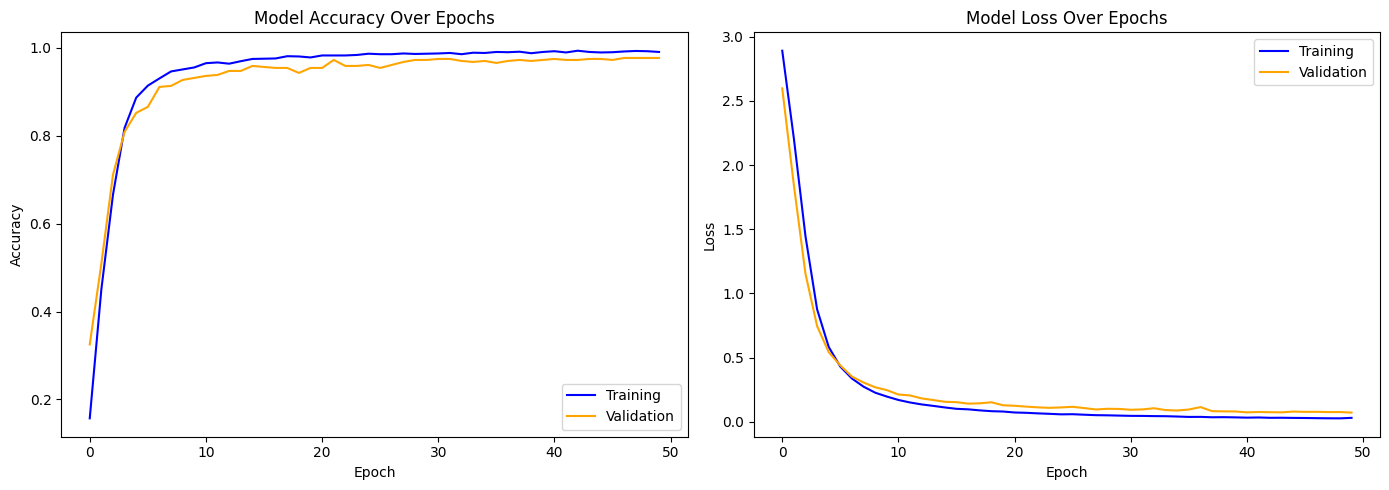

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Training', color='blue')
ax1.plot(history.history['val_accuracy'], label='Validation', color='orange')
ax1.set_title('Model Accuracy Over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

# Loss plot
ax2.plot(history.history['loss'], label='Training', color='blue')
ax2.plot(history.history['val_loss'], label='Validation', color='orange')
ax2.set_title('Model Loss Over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

In [9]:
# Let's predict for YOUR family's crops conditions!!
# Rice conditions
rice_conditions = [[80, 47, 40, 23, 82, 6.5, 200]]
rice_scaled = scaler.transform(rice_conditions)
prediction = model.predict(rice_scaled)
predicted_crop = le.inverse_transform([np.argmax(prediction)])
print(f"Predicted crop: {predicted_crop[0]}")

# Cotton conditions
cotton_conditions = [[118, 46, 19, 30, 80, 6.5, 100]]
cotton_scaled = scaler.transform(cotton_conditions)
prediction2 = model.predict(cotton_scaled)
predicted_crop2 = le.inverse_transform([np.argmax(prediction2)])
print(f"Predicted crop: {predicted_crop2[0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Predicted crop: rice
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Predicted crop: cotton


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
